# Delivery Performance & Customer Satisfaction

## Objective

This notebook evaluates the operational performance of the Olist marketplace by analyzing delivery efficiency and its impact on customer satisfaction.

Business Questions:

- How long does delivery take?
- Are deliveries usually early or late?
- Which orders experience excessive delays?
- How consistent is the logistics network?

In [1]:
import warnings 
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

In [2]:
project_root = Path.cwd().parent.parent
data_dir = project_root / "datasets" / "Olist"


In [4]:
orders = pd.read_csv(
    data_dir/"olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)
customer = pd.read_csv(
    data_dir/"olist_customers_dataset.csv"
)
reviews = pd.read_csv(
    data_dir/"olist_order_reviews_dataset.csv"
)

order_items = pd.read_csv(
    data_dir/"olist_order_items_dataset.csv"
)

products = pd.read_csv(
    data_dir/"olist_products_dataset.csv"
)

translation = pd.read_csv(data_dir/"product_category_name_translation.csv")

sellers = pd.read_csv(
    data_dir/"olist_sellers_dataset.csv"
)


In [6]:
# creating a master df 
delivery_df = (
    orders
    .merge(customer, on="customer_id")
    .merge(reviews, on="order_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id",how="left")
    .merge(
        translation,
        on="product_category_name",
        how="left"
    )
)
delivery_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,...,27.36,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,...,16.05,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0,NaN
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,...,15.17,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,...,16.05,moveis_decoracao,41.0,432.0,2.0,300.0,35.0,35.0,15.0,furniture_decor
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,299905e3934e9e181bfb2e164dd4b4f8,18075,...,19.77,moveis_escritorio,45.0,527.0,1.0,9750.0,42.0,41.0,42.0,office_furniture


In [ ]:
# keeping only delivered items cause others have no delivery
delivery_df = delivery_df[delivery_df["order_status"]=="delivered"].copy()

In [8]:
# calculating delivery time 
delivery_df["delivery_days"]= (delivery_df["order_delivered_customer_date"]-delivery_df["order_purchase_timestamp"]).dt.days
delivery_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,2.0


In [9]:
# calculating summary statistics 
delivery_df["delivery_days"].describe()

count    110832.000000
mean         12.012036
std           9.445169
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [10]:
fig = px.histogram(
    delivery_df,
    x="delivery_days",
    nbins=40,
    title="Distribution of Delivery Time",
    template="plotly_white"
)
fig.show()

In [11]:
fig = px.box(
    delivery_df,
    y="delivery_days",
    title="Delivery time distribution",
    template="plotly_white"
)
fig.show()

In [12]:
avg_delivery = (
    delivery_df["delivery_days"].mean()
)
median_delivery=(
    delivery_df["delivery_days"].median()
)
print(f"Average Delivery {avg_delivery:.2f}")
print(f"Median Delivery: {median_delivery: .2f}")

Average Delivery 12.01
Median Delivery:  10.00


In [14]:
# calculating delivery delay that is delivered - estimated 
delivery_df["delay_days"]=(
    delivery_df["order_delivered_customer_date"] - delivery_df["order_estimated_delivery_date"]
).dt.days

In [15]:
fig = px.histogram(
    delivery_df,
    x="delay_days",
    nbins=40,
    title="Delivery Delay Distribution",
    template = "plotly_white"
)
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="red"
)
fig.show()


In [16]:
# early vs late deliveries 
delivery_df["delivery_status"]=np.where(
    delivery_df["delay_days"]<=0,
    "On Time / Early",
    "Late"
)

delivery_status=(
    delivery_df["delivery_status"]
    .value_counts()
    .reset_index()
)

delivery_status.columns=[
    "Status",
    "Orders"
]
delivery_status

,Status,Orders
0,On Time / Early,103539
1,Late,7301


In [17]:
fig = px.pie(
    delivery_status,
    names="Status",
    values="Orders",
    title="On-Time vs Late Deliveries",
    template="plotly_white"
)
fig.show()

In [19]:
state_delivery = (
    delivery_df
    .groupby("customer_state")
    .agg(
        AvgDelivery=("delivery_days", "mean"),
        Orders=("order_id","nunique")
    )
    .sort_values(
        "AvgDelivery",
        ascending=False
    )
    .reset_index()
)
state_delivery.head()

,customer_state,AvgDelivery,Orders
0,RR,27.826087,41
1,AP,27.753086,67
2,AM,25.926829,145
3,AL,23.983759,397
4,PA,23.313855,946


In [20]:
fig = px.bar(
    state_delivery.head(10),
    x="AvgDelivery",
    y="customer_state",
    orientation="h",
    title="States with Longest Average Delivery Time",
    template="plotly_white"
)
fig.show()

In [21]:
# fastest states 
fig = px.bar(
    state_delivery.tail(10),
    x="AvgDelivery",
    y="customer_state",
    orientation="h",
    title="Fastest Delivery States",
    template="plotly_white"
)
fig.show()

In [ ]:
# seller delivery performance 
# slowest sellers 
seller_delivery = (
    delivery_df
    .groupby("seller_id")
    .agg(
        AvgDelivery=("delivery_days","mean"),
        Orders=("order_id","nunique")
    )
    .query("Orders>=20")
    .sort_values(
        "AvgDelivery",
        ascending=False
    )
    .reset_index()
)

In [23]:
fig = px.bar(
    seller_delivery.head(15),
    x="AvgDelivery",
    y="seller_id",
    orientation="h",
    title="Slowest Sellers",
    template="plotly_white"
)
fig.update_yaxes(showticklabels=False)
fig.show()

In [24]:
# fastest sellers 
fig = px.bar(
    seller_delivery.tail(15),
    x="AvgDelivery",
    y="seller_id",
    orientation="h",
    title="Fastest Sellers",
    template="plotly_white"
)
fig.update_yaxes(showticklabels=False)
fig.show()

In [25]:
seller_delay=(
    delivery_df
    .groupby("seller_id")
    .agg(
        AvgDelay=("delay_days","mean"),
        Orders=("order_id","count")
    )
    .query("Orders>=20")
    .sort_values(
        "AvgDelay",
        ascending=False
    )
)

In [26]:
fig = px.bar(
    seller_delay.head(15).reset_index(),
    x="AvgDelay",
    y="seller_id",
    orientation="h",
    title="Average Delivery Delay by Seller",
    template="plotly_white"
)
fig.update_yaxes(showticklabels=False)
fig.show()

In [27]:
# review score distribution 
review_dist = (
    delivery_df["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)
review_dist.columns=[
    "Review Score",
    "Count"
]
review_dist

,Review Score,Count
0,1.0,12575
1,2.0,3700
2,3.0,9242
3,4.0,21184
4,5.0,63312


In [29]:
fig = px.bar(
    review_dist,
    x="Review Score",
    y="Count",
    text="Count",
    title="Distribution of Customer Review Scores",
    template="plotly_white"
)
fig.show()


In [30]:
# average review score 
average_rating = delivery_df["review_score"].mean()
print(f"Average Review Score: {average_rating: .2f}")

Average Review Score:  4.08


In [34]:
# delivery time vs Reveiw score 
delivery_rating = (
    delivery_df
    .groupby("review_score")
    .agg(
        Avg_Delivery=("delivery_days","mean")
    )
    .reset_index()
)
delivery_rating


,review_score,Avg_Delivery
0,1.0,19.116192
1,2.0,15.337838
2,3.0,13.579420
3,4.0,11.752644
4,5.0,10.191565


In [35]:
fig = px.bar(
    delivery_rating,
    x="review_score",
    y="Avg_Delivery",
    color="review_score",
    title="Average Delivery Time by Review Score",
    template="plotly_white"
)
fig.show()

In [36]:
corr = delivery_df[
    [
    "delivery_days",
    "delay_days",
    "review_score"
    ]
].corr()
corr

,delivery_days,delay_days,review_score
delivery_days,1.000000,0.597233,-0.304013
delay_days,0.597233,1.000000,-0.229224
review_score,-0.304013,-0.229224,1.000000


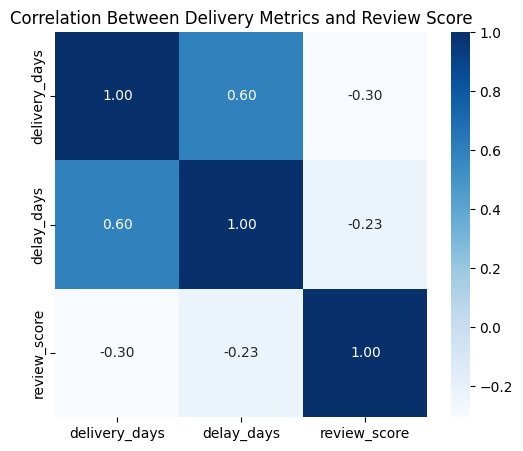

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Correlation Between Delivery Metrics and Review Score")
plt.show()

In [40]:
fig = px.scatter(
    delivery_df.sample(5000),
    x="delivery_days",
    y="review_score",
    opacity=0.4,
    title="Delivery Time vs Customer Rating",
    template="plotly_white"
)

fig.show()

In [41]:
category_rating = (

    delivery_df

    .groupby(

        "product_category_name_english"

    )

    .agg(

        AverageRating=("review_score","mean"),

        Orders=("order_id","count")

    )

    .query("Orders>=30")

    .sort_values(

        "AverageRating",

        ascending=False

    )

    .reset_index()

)

category_rating.head()

,product_category_name_english,AverageRating,Orders
0,books_general_interest,4.512195,537
1,books_imported,4.508772,57
2,costruction_tools_tools,4.444444,103
3,small_appliances_home_oven_and_coffee,4.438356,73
4,flowers,4.419355,33


In [42]:
fig = px.bar(

    category_rating.tail(10),

    x="AverageRating",

    y="product_category_name_english",

    orientation="h",

    title="Lowest Rated Categories",

    template="plotly_white"

)

fig.show()

In [44]:
category_delivery = (

    delivery_df

    .groupby(

        "product_category_name_english"

    )

    .agg(

        AvgDelivery=("delivery_days","mean"),

        Orders=("order_id","count")

    )

    .query("Orders>=30")

    .sort_values(

        "AvgDelivery",

        ascending=False

    )

    .reset_index()

)

In [45]:
fig = px.bar(

    category_delivery.head(10),

    x="AvgDelivery",

    y="product_category_name_english",

    orientation="h",

    title="Slowest Product Categories",

    template="plotly_white"

)

fig.show()

In [46]:
category_analysis = (

    category_delivery

    .merge(

        category_rating,

        on="product_category_name_english"

    )

)

category_analysis.head()

,product_category_name_english,AvgDelivery,Orders_x,AverageRating,Orders_y
0,office_furniture,20.397497,1678,3.517428,1678
1,christmas_supplies,15.300000,150,4.069930,150
2,fashion_shoes,14.965385,260,4.285156,260
3,home_comfort_2,14.066667,30,3.629630,30
4,furniture_mattress_and_upholstery,13.891892,37,3.891892,37


In [50]:
fig = px.scatter(

    category_analysis,

    x="AvgDelivery",

    y="AverageRating",

    size="Orders_x",

    hover_name="product_category_name_english",

    title="Delivery Time vs Customer Rating by Category",

    template="plotly_white"

)

fig.show()

In [52]:
# delivery performance score 
from sklearn.preprocessing import MinMaxScaler

score_df = (

    delivery_df

    .groupby("seller_id")

    .agg(

        AvgDelivery=("delivery_days","mean"),

        AvgDelay=("delay_days","mean"),

        AvgRating=("review_score","mean")

    )

    .reset_index()

)

scaler = MinMaxScaler()

score_df[

    [

        "Delivery_Norm",

        "Delay_Norm",

        "Rating_Norm"

    ]

] = scaler.fit_transform(

    score_df[

        [

            "AvgDelivery",

            "AvgDelay",

            "AvgRating"

        ]

    ]

)

score_df["Delivery_Performance_Score"]=(

    (1-score_df["Delivery_Norm"])*0.40

    +

    (1-score_df["Delay_Norm"])*0.30

    +

    score_df["Rating_Norm"]*0.30

)

score_df.head()

,seller_id,AvgDelivery,AvgDelay,AvgRating,Delivery_Norm,Delay_Norm,Rating_Norm,Delivery_Performance_Score
0,0015a82c2db000af6aaaf3ae2ecb0532,10.333333,-16.333333,3.666667,0.049645,0.213162,0.666667,0.816193
1,001cca7ae9ae17fb1caed9dfb1094831,12.628205,-13.213675,3.965368,0.061852,0.226551,0.741342,0.829697
2,002100f778ceb8431b7a1020ff7ab48f,15.636364,-8.218182,4.036364,0.077853,0.247991,0.759091,0.822189
3,003554e2dce176b5555353e4f3555ac8,4.000000,-27.000000,5.000000,0.015957,0.167382,1.000000,0.943402
4,004c9cd9d87a3c30c522c48c4fc07416,14.327586,-11.614943,4.145349,0.070891,0.233412,0.786337,0.837521


In [53]:
fig = px.histogram(

    score_df,

    x="Delivery_Performance_Score",

    nbins=25,

    title="Distribution of Delivery Performance Score",

    template="plotly_white"

)

fig.show()

# Delivery Performance & Customer Satisfaction Insights

## 1. Delivery Performance

- The average delivery time across the marketplace is **12.01 days**, while the median delivery time is **10 days**.
- The difference between the mean and median indicates a right-skewed distribution, where most deliveries are completed within a reasonable timeframe but a small number of orders experience substantial delays.
- Some deliveries take more than **200 days**, highlighting extreme operational outliers that should be investigated separately.

---

## 2. Delivery Reliability

- Out of approximately **110,840 delivered orders**, **103,539 orders (93.4%)** were delivered on or before the promised delivery date.
- Only **7,301 orders (6.6%)** were delivered late.
- This indicates that Olist maintains a highly reliable logistics network with strong on-time delivery performance.

---

## 3. Regional Delivery Performance

- Delivery performance varies considerably across Brazilian states.
- States such as **Roraima (RR), Amapá (AP), Amazonas (AM), Alagoas (AL), and Pará (PA)** experience the longest average delivery times.
- These longer delivery times are likely influenced by geographic distance, transportation infrastructure, and logistics complexity.
- Regional logistics optimization should prioritize these states to improve customer experience.

---

## 4. Customer Satisfaction

- The marketplace maintains a high level of customer satisfaction with an average review score of **4.08 out of 5**.
- Five-star ratings dominate the review distribution (**63,312 reviews**), while one-star ratings account for only **12,575 reviews**.
- Overall, customers appear satisfied with their purchasing experience.

---

## 5. Relationship Between Delivery and Customer Ratings

- Delivery performance has a measurable impact on customer satisfaction.
- Customers giving **1-star ratings** experienced an average delivery time of approximately **19.1 days**.
- Customers giving **5-star ratings** received their orders in approximately **10.2 days** on average.
- This nearly **9-day difference** demonstrates that faster deliveries are strongly associated with higher customer satisfaction.

---

## 6. Correlation Analysis

- Delivery time and review score show a **moderate negative correlation (-0.30)**.
- Delivery delays and review scores also exhibit a negative correlation (**-0.23**).
- These findings indicate that while delivery performance influences customer satisfaction, other factors such as product quality, pricing, packaging, and customer expectations also contribute to review ratings.

---

## 7. Product Category Performance

- Customer satisfaction varies across different product categories.
- Categories such as **Books**, **Imported Books**, and **Construction Tools** achieve the highest average customer ratings.
- In contrast, categories such as **Office Furniture** experience longer delivery times and comparatively lower customer ratings.
- Bulky or complex products appear more susceptible to logistics challenges.

---

## 8. Delivery Performance Score

- The Delivery Performance Score successfully combines delivery speed, delivery delays, and customer ratings into a single operational KPI.
- This score enables objective comparison of seller logistics performance rather than relying solely on delivery time.
- It provides a practical framework for identifying operational leaders and sellers requiring logistics improvements.

---

# Strategic Business Recommendations

### Improve Long-Distance Logistics

Prioritize logistics improvements in northern and remote states where delivery times are consistently higher.

---

### Reduce Delivery Delays

Although only **6.6%** of orders are delivered late, reducing these delays could have a significant positive impact on customer satisfaction and repeat purchases.

---

### Monitor Low-Performing Categories

Product categories with long delivery times and lower ratings should be reviewed to identify issues related to packaging, fulfillment, inventory management, or transportation.

---

### Introduce Operational KPIs

Adopt the **Delivery Performance Score** as a standard operational metric to monitor seller logistics performance and identify improvement opportunities.

---

### Strengthen Customer Experience

Since delivery performance has a measurable influence on customer satisfaction, investments in logistics optimization are likely to improve customer ratings, retention, and long-term customer lifetime value.